In [1]:
## General imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch
import seaborn as sns
import pandas as pd
import pingouin as pg
## Latex fonts
from set_tex_fonts import set_latex_font

In [2]:
# Size of one plot and resolution
pltSizex = 10
pltSizey = 10
dpi = 300
# Fontsize for the different parameters
legFont = 55
xTitleFont = 50
yTitleFont = 50
xLabelFont = 40
yLabelFont = 40
# Set latex font for plots
set_latex_font()

In [3]:
## Parameters
ablationsList = ['None', 'all_but_pos', 'all_but_posvel', 'forcestorques', 'all_but_forcestorques', 'all_but_forcestorquesant', 'velocity', 'anthropo', 'forces', 'torques', 'Fx', 'Fy', 'Fz', 'Tx', 'Ty', 'Tz']
ablLabels     = [r'Full',r'$\mathbf{q}_r$', r'$[\mathbf{q}_r, \dot{\mathbf{q}}_r]$', r'$[\mathbf{q}_r, \dot{\mathbf{q}}_r, \mathbf{\ell}_h]$', r'$[\mathbf{F}_i, \dot{\bm{\tau}}_i]$', r'$[\mathbf{F}_i, \dot{\bm{\tau}}_i, \mathbf{\ell}_h]$', r'$\overline{\dot{\mathbf{q}}_r}$', r'$\overline{\mathbf{\ell}_h}$', r'$\overline{\mathbf{F}_i}$', r'$\overline{\bm{\tau}_i}$', r'$\overline{F_x}$', r'$\overline{F_y}$', r'$\overline{F_z}$', r'$\overline{\tau_x}$', r'$\overline{\tau_y}$', r'$\overline{\tau_z}$']
outTypesList  = ['pos', 'vel', 'posvel']
foldsList     = ['2-fold', '3-fold']
jointsList    = ['shoulder', 'elbow']

In [4]:
## Import all fitting results
all_MVLRFittings = pd.read_csv('./all_params/all_MVLR_fitting_results.csv', keep_default_na = False, na_values = ['NaN', 'N/A', ''])

posFittingMVLR = all_MVLRFittings[all_MVLRFittings['predicted'] == 'pos']
velFittingMVLR = all_MVLRFittings[all_MVLRFittings['predicted'] == 'vel']
fullFittingMVLR = all_MVLRFittings[all_MVLRFittings['predicted'] == 'posvel']

## Extract different MVLR results
# Position fitting only
posTrainRes_MVLR  = posFittingMVLR[posFittingMVLR['type'] == 'train']
posTrainRes_MVLR_s = posTrainRes_MVLR[posTrainRes_MVLR['joint'] == 'shoulder']
posTrainRes_MVLR_e = posTrainRes_MVLR[posTrainRes_MVLR['joint'] == 'elbow']
posEvalRes_MVLR   = posFittingMVLR[posFittingMVLR['type'] == 'eval']
posEvalRes_MVLR_s = posEvalRes_MVLR[posEvalRes_MVLR['joint'] == 'shoulder']
posEvalRes_MVLR_e = posEvalRes_MVLR[posEvalRes_MVLR['joint'] == 'elbow']
# Velocity fitting only
velTrainRes_MVLR   = velFittingMVLR[velFittingMVLR['type'] == 'train']
velTrainRes_MVLR_s = velTrainRes_MVLR[velTrainRes_MVLR['joint'] == 'shoulder']
velTrainRes_MVLR_e = velTrainRes_MVLR[velTrainRes_MVLR['joint'] == 'elbow']
velEvalRes_MVLR   = velFittingMVLR[velFittingMVLR['type'] == 'eval']
velEvalRes_MVLR_s = velEvalRes_MVLR[velEvalRes_MVLR['joint'] == 'shoulder']
velEvalRes_MVLR_e = velEvalRes_MVLR[velEvalRes_MVLR['joint'] == 'elbow']
# Full fitting
fullTrainRes_MVLR   = fullFittingMVLR[fullFittingMVLR['type'] == 'train']
fullTrainRes_MVLR_s = fullTrainRes_MVLR[fullTrainRes_MVLR['joint'] == 'shoulder']
fullTrainRes_MVLR_e = fullTrainRes_MVLR[fullTrainRes_MVLR['joint'] == 'elbow']
fullEvalRes_MVLR   = fullFittingMVLR[fullFittingMVLR['type'] == 'eval']
fullEvalRes_MVLR_s = fullEvalRes_MVLR[fullEvalRes_MVLR['joint'] == 'shoulder']
fullEvalRes_MVLR_e = fullEvalRes_MVLR[fullEvalRes_MVLR['joint'] == 'elbow']

# FOLDING EFFECT

In [5]:
## Group by subject to compare effects
# Training sets
posTrainRes_MVLR_s_subj  = posTrainRes_MVLR_s.groupby(['subject', 'fold', 'joint']).mean(numeric_only = True).reset_index()
posTrainRes_MVLR_e_subj  = posTrainRes_MVLR_e.groupby(['subject', 'fold', 'joint']).mean(numeric_only = True).reset_index()
velTrainRes_MVLR_s_subj  = velTrainRes_MVLR_s.groupby(['subject', 'fold', 'joint']).mean(numeric_only = True).reset_index()
velTrainRes_MVLR_e_subj  = velTrainRes_MVLR_e.groupby(['subject', 'fold', 'joint']).mean(numeric_only = True).reset_index()
fullTrainRes_MVLR_s_subj = fullTrainRes_MVLR_s.groupby(['subject', 'fold', 'joint']).mean(numeric_only = True).reset_index()
fullTrainRes_MVLR_e_subj = fullTrainRes_MVLR_e.groupby(['subject', 'fold', 'joint']).mean(numeric_only = True).reset_index()
# Regroup for plot with joint hue
posTrainRes_MVLR_se_subj = pd.concat([posTrainRes_MVLR_s_subj, posTrainRes_MVLR_e_subj], axis = 0, ignore_index = True)
velTrainRes_MVLR_se_subj = pd.concat([velTrainRes_MVLR_s_subj, velTrainRes_MVLR_e_subj], axis = 0, ignore_index = True)
fullTrainRes_MVLR_se_subj = pd.concat([fullTrainRes_MVLR_s_subj, fullTrainRes_MVLR_e_subj], axis = 0, ignore_index = True)
# Evaluation sets
posEvalRes_MVLR_s_subj = posEvalRes_MVLR_s.groupby(['subject', 'fold', 'joint']).mean(numeric_only = True).reset_index()
posEvalRes_MVLR_e_subj = posEvalRes_MVLR_e.groupby(['subject', 'fold', 'joint']).mean(numeric_only = True).reset_index()
velEvalRes_MVLR_s_subj = velEvalRes_MVLR_s.groupby(['subject', 'fold', 'joint']).mean(numeric_only = True).reset_index()
velEvalRes_MVLR_e_subj = velEvalRes_MVLR_e.groupby(['subject', 'fold', 'joint']).mean(numeric_only = True).reset_index()
fullEvalRes_MVLR_s_subj = fullEvalRes_MVLR_s.groupby(['subject', 'fold', 'joint']).mean(numeric_only = True).reset_index()
fullEvalRes_MVLR_e_subj = fullEvalRes_MVLR_e.groupby(['subject', 'fold', 'joint']).mean(numeric_only = True).reset_index()
# Regroup for plot with joint hue
posEvalRes_MVLR_se_subj = pd.concat([posEvalRes_MVLR_s_subj, posEvalRes_MVLR_e_subj], axis = 0, ignore_index = True)
velEvalRes_MVLR_se_subj = pd.concat([velEvalRes_MVLR_s_subj, velEvalRes_MVLR_e_subj], axis = 0, ignore_index = True)
fullEvalRes_MVLR_se_subj = pd.concat([fullEvalRes_MVLR_s_subj, fullEvalRes_MVLR_e_subj], axis = 0, ignore_index = True)

In [6]:
def set_axis_fig_fold_effect(fig, axes, palette):
    axes[0,0].set_xlabel(xlabel=r'', fontsize = xTitleFont)
    axes[0,0].set_xticks(['shoulder','elbow'])
    axes[0,0].set_xticklabels(['',''], size = xLabelFont)
    axes[0,0].set_ylabel(r'Pos. AAE ($\mathrm{rad}$)', fontsize = xTitleFont)
    axes[0,0].set_yticks([0.1,0.2,0.3,0.4])
    axes[0,0].set_yticklabels([0.1,0.2,0.3,0.4], size = xLabelFont)
    axes[0,0].set_ylim([0.1,0.4])

    box_patches = [p for p in axes[0,0].patches if isinstance(p, PathPatch)]
    for patch, color in zip(box_patches, palette):
        patch.set_facecolor(color)

    axes[0,1].set_xlabel(xlabel=r'', fontsize = xTitleFont)
    axes[0,1].set_xticks(['shoulder','elbow'])
    axes[0,1].set_xticklabels(['',''], size = xLabelFont)
    axes[0,1].set_ylabel(r'Vel. AAE ($10^{-3}\cdot\mathrm{rad/s}$)', fontsize = xTitleFont)
    axes[0,1].set_yticks([0.002,0.004,0.006])
    axes[0,1].set_yticklabels([2,4,6], size = xLabelFont)
    axes[0,1].set_ylim([0.002,0.007])

    box_patches = [p for p in axes[0,1].patches if isinstance(p, PathPatch)]
    for patch, color in zip(box_patches, palette):
        patch.set_facecolor(color)

    axes[0,2].set_xlabel(xlabel=r'', fontsize = xTitleFont)
    axes[0,2].set_xticks(['shoulder','elbow'])
    axes[0,2].set_xticklabels(['',''], size = xLabelFont)
    axes[0,2].set_ylabel(r'Torque AAE ($\mathrm{Nm}$)', fontsize = xTitleFont)
    axes[0,2].set_yticks([0,1,2,3])
    axes[0,2].set_yticklabels([0,1,2,3], size = xLabelFont)
    axes[0,2].set_ylim([0,3])

    box_patches = [p for p in axes[0,2].patches if isinstance(p, PathPatch)]
    for patch, color in zip(box_patches, palette):
        patch.set_facecolor(color)


    axes[1,0].set_xlabel(xlabel=r'', fontsize = xTitleFont)
    axes[1,0].set_xticks(['shoulder','elbow'])
    axes[1,0].set_xticklabels(['Shoulder','Elbow'], size = xLabelFont)
    axes[1,0].set_ylabel(r'Pos. AAE ($\mathrm{rad}$)', fontsize = xTitleFont)
    axes[1,0].set_yticks([0.1,0.2,0.3,0.4])
    axes[1,0].set_yticklabels([0.1,0.2,0.3,0.4], size = xLabelFont)
    axes[1,0].set_ylim([0.1,0.45])

    box_patches = [p for p in axes[1,0].patches if isinstance(p, PathPatch)]
    for patch, color in zip(box_patches, palette):
        patch.set_facecolor(color)

    axes[1,1].set_xlabel(xlabel=r'', fontsize = xTitleFont)
    axes[1,1].set_xticks(['shoulder','elbow'])
    axes[1,1].set_xticklabels(['Shoulder','Elbow'], size = xLabelFont)
    axes[1,1].set_ylabel(r'Vel. AAE ($10^{-3}\cdot\mathrm{rad/s}$)', fontsize = xTitleFont)
    axes[1,1].set_yticks([0.002,0.004,0.006])
    axes[1,1].set_yticklabels([2,4,6], size = xLabelFont)
    axes[1,1].set_ylim([0.002,0.0075])

    box_patches = [p for p in axes[1,1].patches if isinstance(p, PathPatch)]
    for patch, color in zip(box_patches, palette):
        patch.set_facecolor(color)

    axes[1,2].set_xlabel(xlabel=r'', fontsize = xTitleFont)
    axes[1,2].set_xticks(['shoulder','elbow'])
    axes[1,2].set_xticklabels(['Shoulder','Elbow'], size = xLabelFont)
    axes[1,2].set_ylabel(r'Torque AAE ($\mathrm{Nm}$)', fontsize = xTitleFont)
    axes[1,2].set_yticks([0,1,2,3])
    axes[1,2].set_yticklabels([0,1,2,3], size = xLabelFont)
    axes[1,2].set_ylim([0,3])

    box_patches = [p for p in axes[1,2].patches if isinstance(p, PathPatch)]
    for patch, color in zip(box_patches, palette):
        patch.set_facecolor(color)

    for axs in axes:
        for ax in axs:
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(4)
            ax.spines['bottom'].set_linewidth(4)
            ax.tick_params(width = 4, length = 12)
            ax.set_axisbelow(True)
            #ax.legend().remove()

/tmp/ipykernel_10645/448472951.py:13: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.boxplot(x = 'joint', y = 'posAAE', data = fullTrainRes_MVLR_se_subj, hue = 'fold', palette = palette, linecolor = 'k', linewidth = 3, showfliers=False, ax = axes[0,0])
/tmp/ipykernel_10645/448472951.py:16: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.boxplot(x = 'joint', y = 'velAAE', data = fullTrainRes_MVLR_se_subj, hue = 'fold', palette = palette, linecolor = 'k', linewidth = 3, showfliers=False, ax = axes[0,1])
/tmp/ipykernel_10645/448472951.py:19: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.boxplot(x = 'joint', y = 'tauAAE', data = fullTrainRes_MVLR_se_subj, hue = 'fold', palette = palette, linecolor = 'k', linewidth = 3, showfliers=False, ax = axes[0,2])
/tmp/ipykernel_10645/448472951.py:22: UserWarning: The palette list has more value

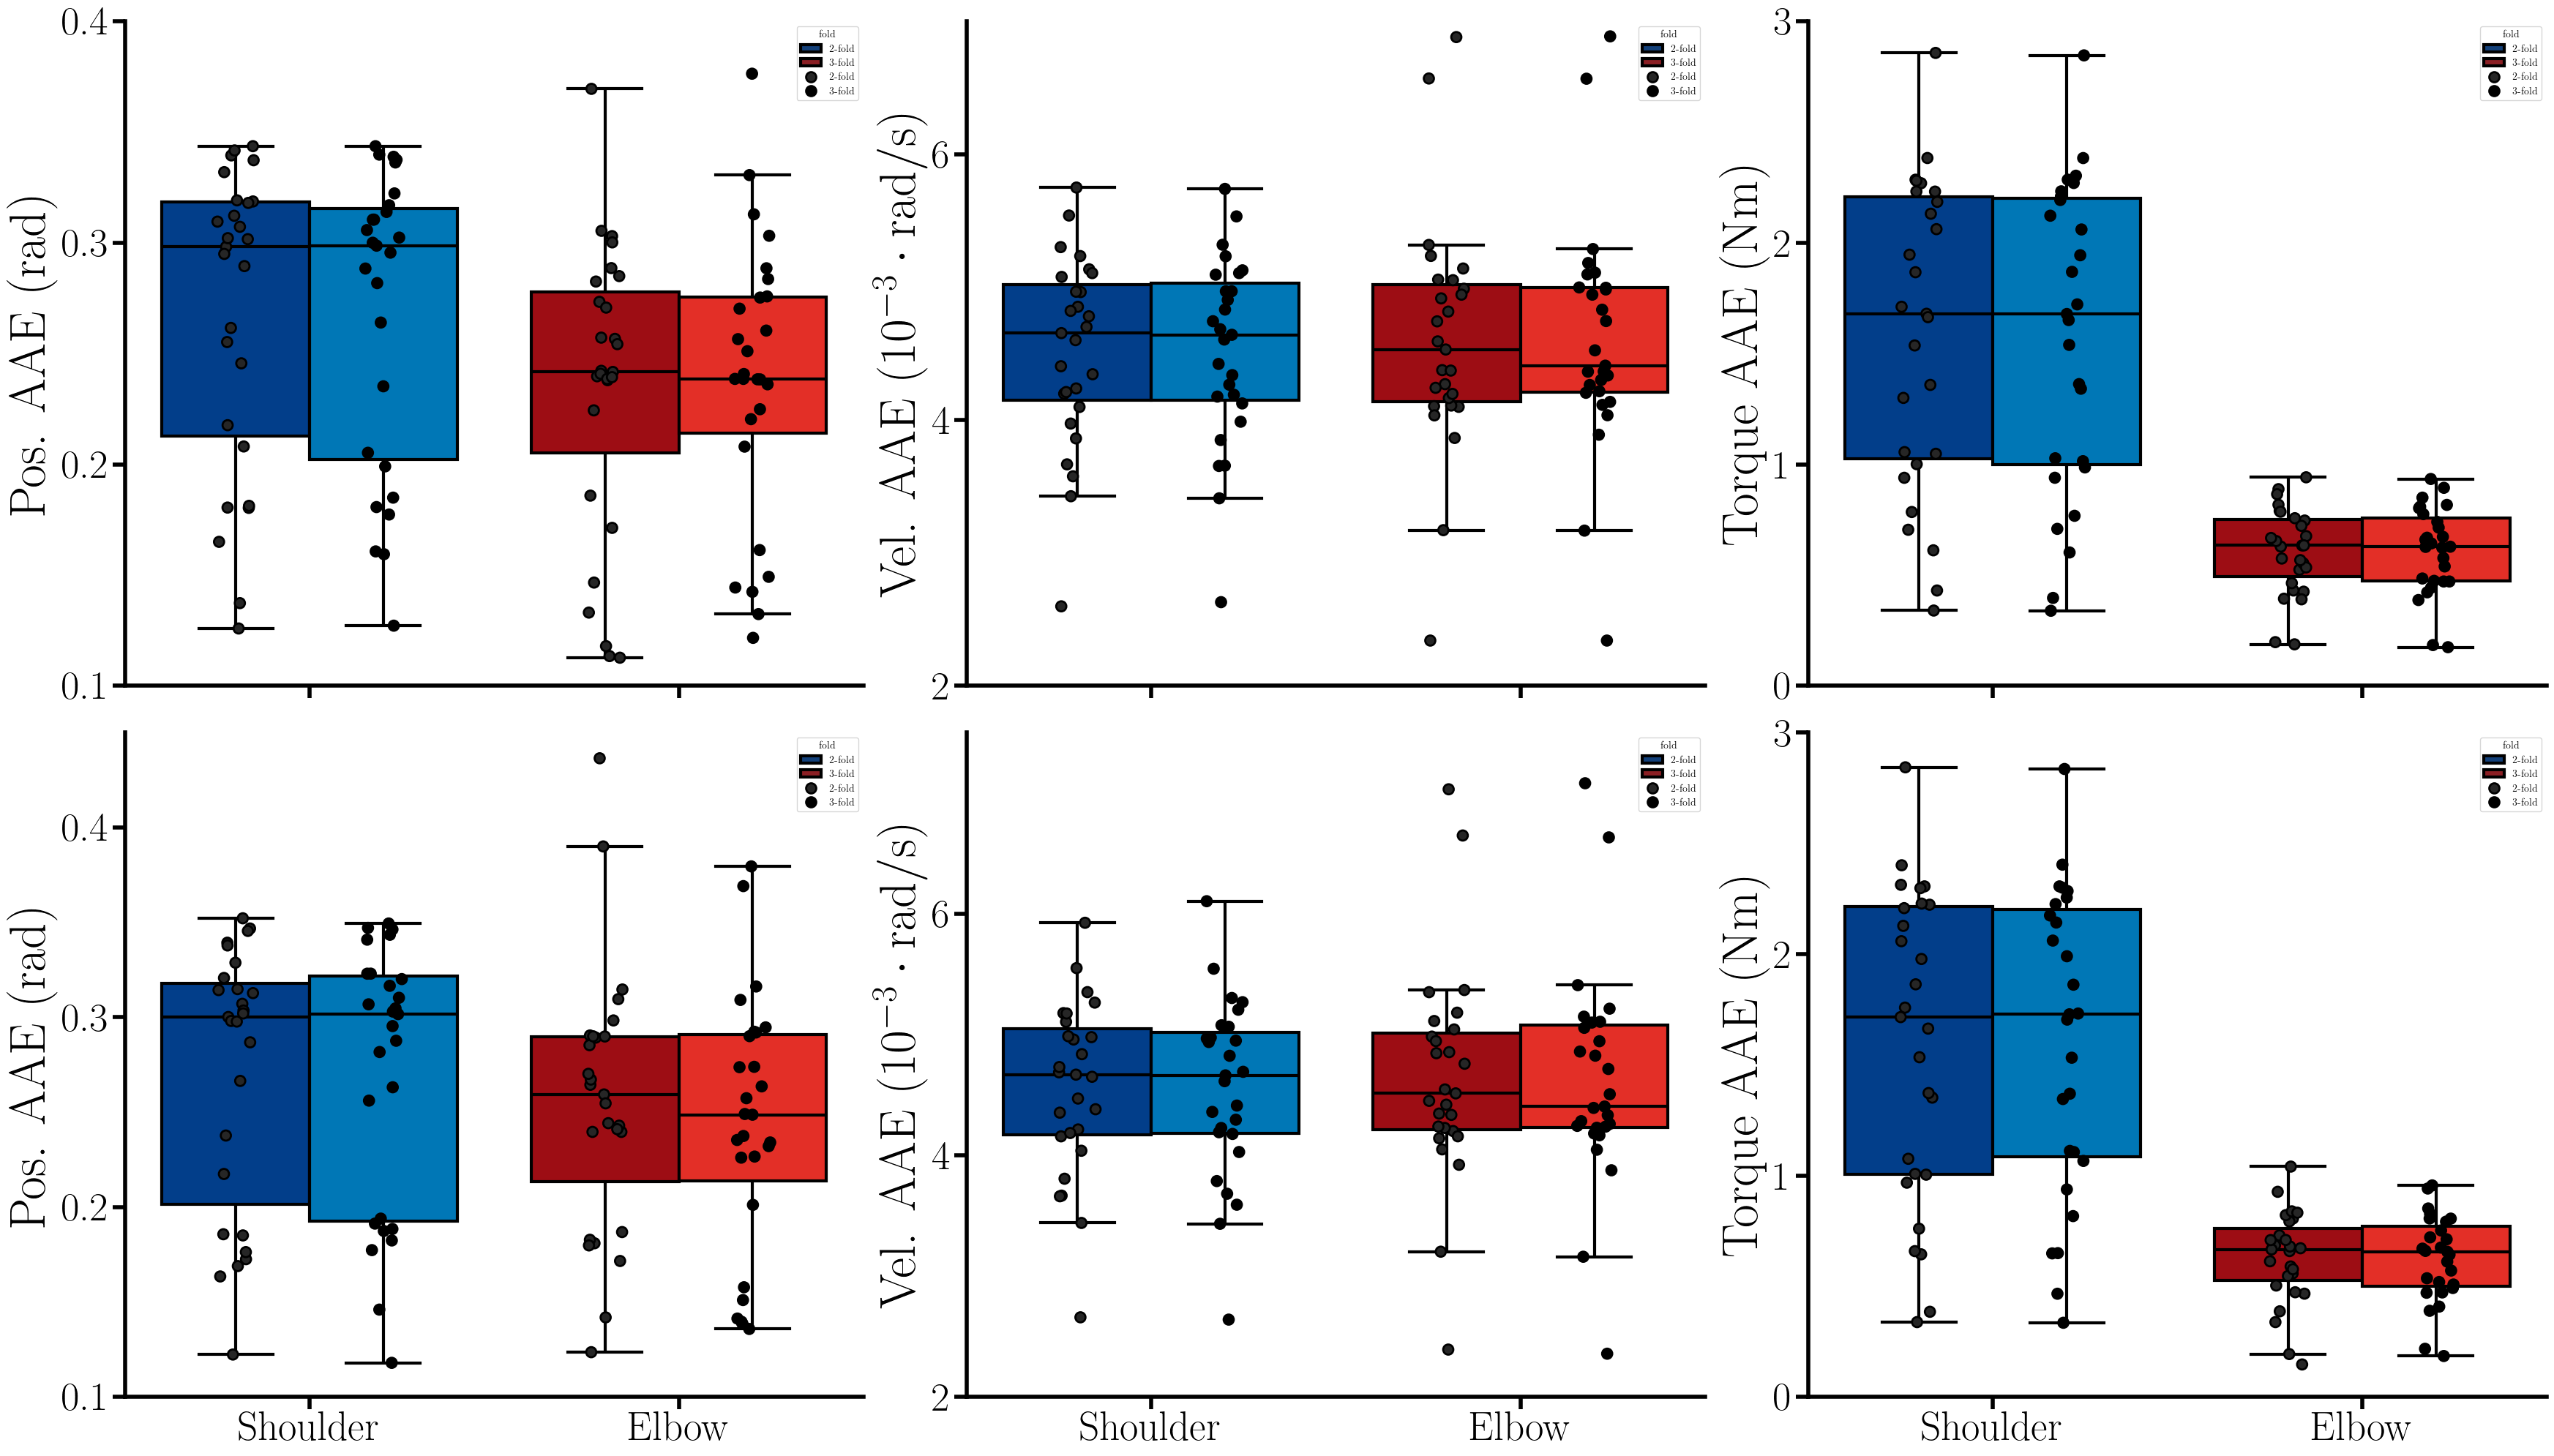

In [7]:
## Palette for shoulder and elbow
cmap_sho = ["#023e8a", "#0077b6"] #,"#ade8f4"
cmap_elb = ['#9d0d14', '#e32f27'] # '#fcc4ad',

palette = []
for i in range(0,len(cmap_sho)):
    palette.append(cmap_sho[i])
    palette.append(cmap_elb[i])

## Effect of fold on training dataset when fitting pos only
fig, axes = plt.subplots(2, 3, figsize = (3.5*pltSizex, 2*pltSizex), sharex = True)

sns.boxplot(x = 'joint', y = 'posAAE', data = fullTrainRes_MVLR_se_subj, hue = 'fold', palette = palette, linecolor = 'k', linewidth = 3, showfliers=False, ax = axes[0,0])
sns.stripplot(x = 'joint', y = 'posAAE', data = fullTrainRes_MVLR_se_subj, hue = 'fold', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[0,0])

sns.boxplot(x = 'joint', y = 'velAAE', data = fullTrainRes_MVLR_se_subj, hue = 'fold', palette = palette, linecolor = 'k', linewidth = 3, showfliers=False, ax = axes[0,1])
sns.stripplot(x = 'joint', y = 'velAAE', data = fullTrainRes_MVLR_se_subj, hue = 'fold', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[0,1])

sns.boxplot(x = 'joint', y = 'tauAAE', data = fullTrainRes_MVLR_se_subj, hue = 'fold', palette = palette, linecolor = 'k', linewidth = 3, showfliers=False, ax = axes[0,2])
sns.stripplot(x = 'joint', y = 'tauAAE', data = fullTrainRes_MVLR_se_subj, hue = 'fold', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[0,2])

sns.boxplot(x = 'joint', y = 'posAAE', data = fullEvalRes_MVLR_se_subj, hue = 'fold', palette = palette, linecolor = 'k', linewidth = 3, showfliers=False, ax = axes[1,0])
sns.stripplot(x = 'joint', y = 'posAAE', data = fullEvalRes_MVLR_se_subj, hue = 'fold', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[1,0])

sns.boxplot(x = 'joint', y = 'velAAE', data = fullEvalRes_MVLR_se_subj, hue = 'fold', palette = palette, linecolor = 'k', linewidth = 3, showfliers=False, ax = axes[1,1])
sns.stripplot(x = 'joint', y = 'velAAE', data = fullEvalRes_MVLR_se_subj, hue = 'fold', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[1,1])

sns.boxplot(x = 'joint', y = 'tauAAE', data = fullEvalRes_MVLR_se_subj, hue = 'fold', palette = palette, linecolor = 'k', linewidth = 3, showfliers=False, ax = axes[1,2])
sns.stripplot(x = 'joint', y = 'tauAAE', data = fullEvalRes_MVLR_se_subj, hue = 'fold', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[1,2])

set_axis_fig_fold_effect(fig, axes, palette)

fig.tight_layout()

plt.savefig('./Unprocessed_Figures/MVLR_NoFoldEffect.svg', format='svg')

# INPUT ABLATION EFFECT

In [8]:
## Group by input ablation type
full_fittingMVLR_ablation = fullFittingMVLR.groupby(['subject', 'type', 'joint', 'ablation']).mean(numeric_only = True).reset_index()
# Split training and evaluation data
fullTrainMVLR_ablation = full_fittingMVLR_ablation[full_fittingMVLR_ablation['type'] == 'train']
fullEvalMVLR_ablation  = full_fittingMVLR_ablation[full_fittingMVLR_ablation['type'] == 'eval']

In [9]:
def set_axis_fig_ablation_effect(fig, axes):
    palette = ['red', 'royalblue', 'salmon', 'lightblue']
    axes[0,0].set_xticks(ablationsList)
    axes[0,0].set_ylabel(r'Pos. AAE ($\mathrm{rad}$)', fontsize = xTitleFont)
    axes[0,0].set_yticks([0,0.1,0.2,0.3,0.4])
    axes[0,0].set_yticklabels([0,0.1,0.2,0.3,0.4], size = xLabelFont)
    axes[0,0].set_ylim([0,0.45])

    axes[1,0].set_xticks(ablationsList)
    axes[1,0].set_ylabel(r'Vel. AAE ($10^{-3}\cdot\mathrm{rad/s}$)', fontsize = xTitleFont)
    axes[1,0].set_yticks([0,0.005,0.01,0.015])
    axes[1,0].set_yticklabels([0,5,10,15], size = xLabelFont)
    axes[1,0].set_ylim([0,0.015])

    axes[2,0].set_xlabel(xlabel=r'', fontsize = xTitleFont)
    axes[2,0].set_xticks(ablationsList)
    axes[2,0].set_xticklabels(ablLabels, size = xLabelFont, rotation = 75)
    axes[2,0].set_ylabel(r'Torque AAE ($\mathrm{Nm}$)', fontsize = xTitleFont)
    axes[2,0].set_yticks([1,2,3])
    axes[2,0].set_yticklabels([1,2,3], size = xLabelFont)
    axes[2,0].set_ylim([0,3])

    axes[2,1].set_xlabel(xlabel=r'', fontsize = xTitleFont)
    axes[2,1].set_xticks(ablationsList)
    axes[2,1].set_xticklabels(ablLabels, size = xLabelFont, rotation = 75)

    for axs in axes:
        for ax in axs:
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(4)
            ax.spines['bottom'].set_linewidth(4)
            ax.tick_params(width = 4, length = 12)
            ax.set_axisbelow(True)
            #ax.legend().remove()

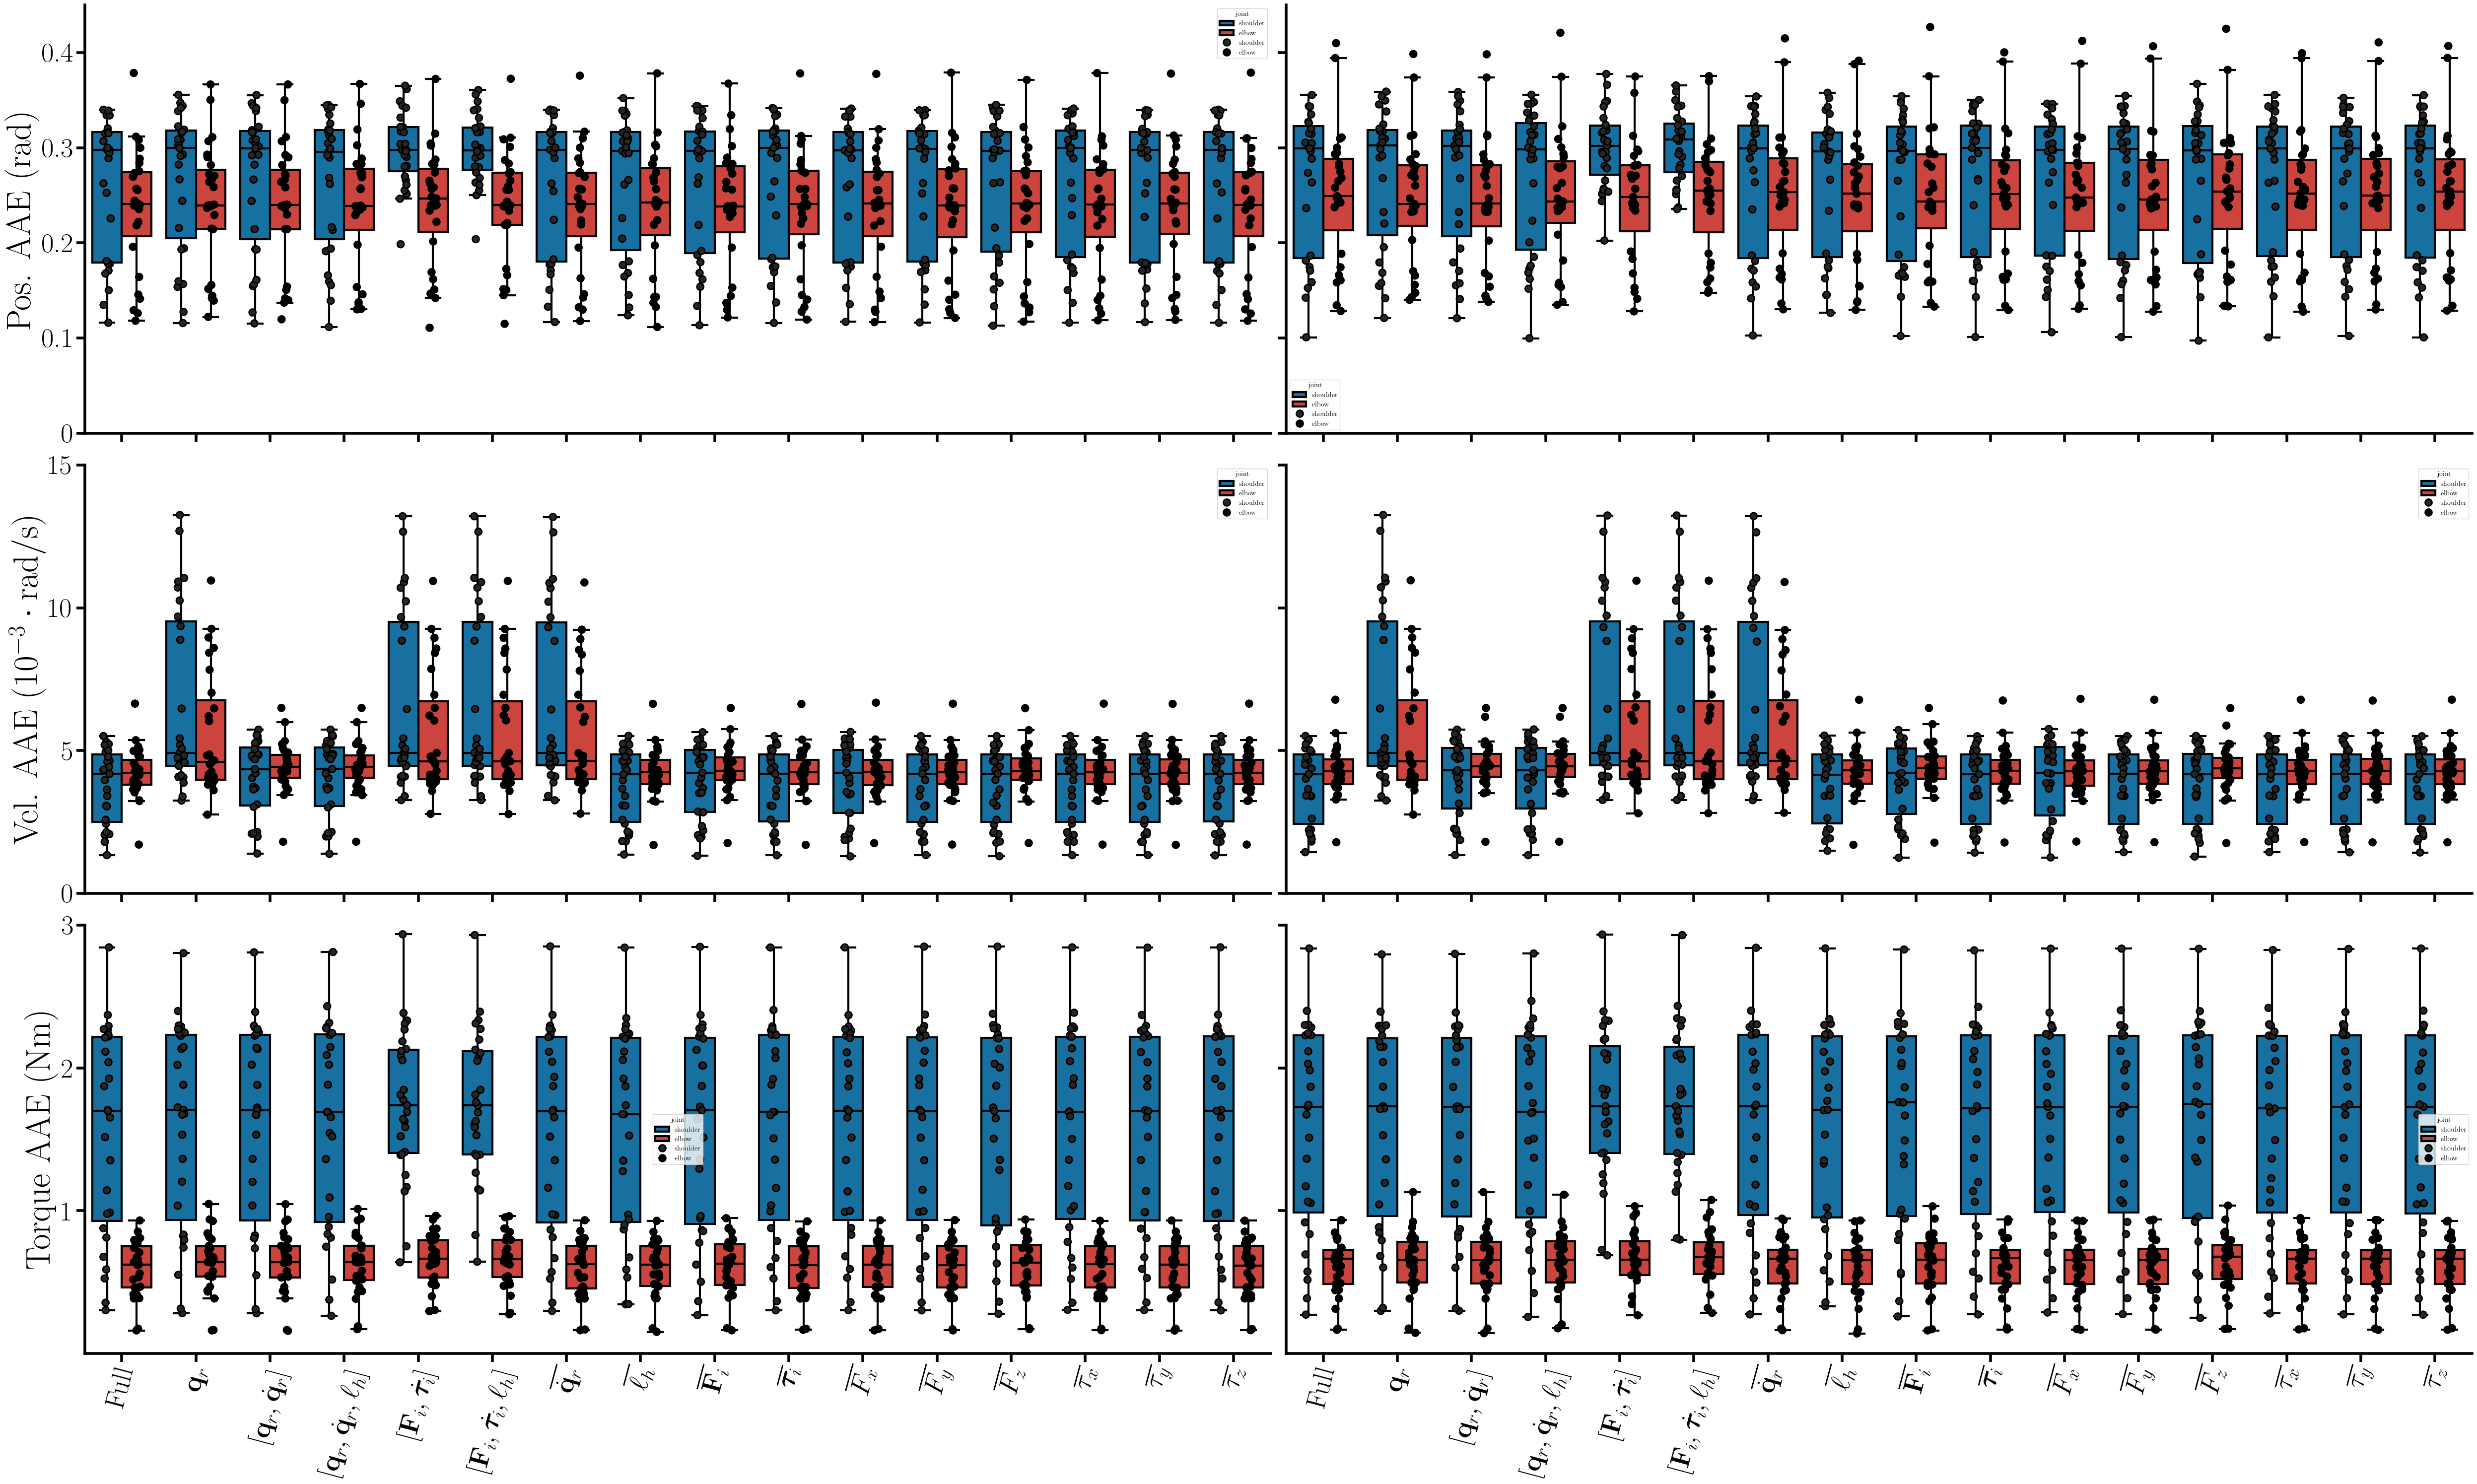

In [10]:
palette = ["#0077b6", "#e32f27"]

fig, axes = plt.subplots(3, 2, figsize = (5*pltSizex, 3*pltSizex), sharex = True, sharey = 'row')

sns.boxplot(x = 'ablation', y = 'posAAE', data = fullTrainMVLR_ablation, hue = 'joint', order = ablationsList, hue_order = jointsList, palette = palette, linecolor = 'k', linewidth = 3, showfliers=False, ax = axes[0,0])
sns.stripplot(x = 'ablation', y = 'posAAE', data = fullTrainMVLR_ablation, hue = 'joint', order = ablationsList, hue_order = jointsList, palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[0,0])

sns.boxplot(x = 'ablation', y = 'velAAE', data = fullTrainMVLR_ablation, hue = 'joint', order = ablationsList, hue_order = jointsList, palette = palette, linecolor = 'k', linewidth = 3, showfliers=False, ax = axes[1,0])
sns.stripplot(x = 'ablation', y = 'velAAE', data = fullTrainMVLR_ablation, hue = 'joint', order = ablationsList, hue_order = jointsList, palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[1,0])

sns.boxplot(x = 'ablation', y = 'tauAAE', data = fullTrainMVLR_ablation, hue = 'joint', order = ablationsList, hue_order = jointsList, palette = palette, linecolor = 'k', linewidth = 3, showfliers=False, ax = axes[2,0])
sns.stripplot(x = 'ablation', y = 'tauAAE', data = fullTrainMVLR_ablation, hue = 'joint', order = ablationsList, hue_order = jointsList, palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[2,0])

sns.boxplot(x = 'ablation', y = 'posAAE', data = fullEvalMVLR_ablation, hue = 'joint', order = ablationsList, hue_order = jointsList, palette = palette, linecolor = 'k', linewidth = 3, showfliers=False, ax = axes[0,1])
sns.stripplot(x = 'ablation', y = 'posAAE', data = fullEvalMVLR_ablation, hue = 'joint', order = ablationsList, hue_order = jointsList, palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[0,1])

sns.boxplot(x = 'ablation', y = 'velAAE', data = fullEvalMVLR_ablation, hue = 'joint', order = ablationsList, hue_order = jointsList, palette = palette, linecolor = 'k', linewidth = 3, showfliers=False, ax = axes[1,1])
sns.stripplot(x = 'ablation', y = 'velAAE', data = fullEvalMVLR_ablation, hue = 'joint', order = ablationsList, hue_order = jointsList, palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[1,1])

sns.boxplot(x = 'ablation', y = 'tauAAE', data = fullEvalMVLR_ablation, hue = 'joint', order = ablationsList, hue_order = jointsList, palette = palette, linecolor = 'k', linewidth = 3, showfliers=False, ax = axes[2,1])
sns.stripplot(x = 'ablation', y = 'tauAAE', data = fullEvalMVLR_ablation, hue = 'joint', order = ablationsList, hue_order = jointsList, palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[2,1])

set_axis_fig_ablation_effect(fig, axes)

fig.tight_layout()

plt.savefig('./Unprocessed_Figures/MVLR_LimitedAblationEffect.svg', format='svg')